# 02 - EDA dirigido a la problemática (es_incapacitante)

A diferencia de `01_eda_accidentes.ipynb` (descriptivo, sobre 2023-2024),
este notebook trabaja **solo sobre `accidentes_historico_2012_2022.csv`**
(única fuente con `gravedad`) y evalúa las X candidatas contra la variable
objetivo `es_incapacitante` (ver README, secciones 4-5, y
`reports/diccionario_datos.md`), organizado en 6 preguntas.

La lógica vive en `src/clean.py` (`derive_es_incapacitante`,
`normalize_turno`) y `src/eda.py` (`cramers_v`,
`tasa_incapacitante_por_categoria`) — este notebook solo importa y muestra.

**Las celdas `### Hallazgo` se dejan en blanco a propósito**: este
notebook calcula, no interpreta — la lectura de cada resultado la completa
el equipo después de revisarlo (ver CLAUDE.md: prohibido inventar
conclusiones).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sys.path.append(str(Path.cwd().parent))

from src.clean import derive_es_incapacitante
from src.config import FIGURES_DIR
from src.eda import cramers_v, tasa_incapacitante_por_categoria
from src.ingest import load_historico_accidentes

sns.set_theme()
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

df = load_historico_accidentes()
y = derive_es_incapacitante(df["gravedad"])

print("shape df:", df.shape)
print("filas con etiqueta definida:", y.notna().sum(), "de", len(df))

shape df: (1028, 27)
filas con etiqueta definida: 1016 de 1028


## Pregunta 1: ¿Cómo se distribuye la variable objetivo `es_incapacitante`?

Necesario para saber qué tan desbalanceado está el problema de
clasificación antes de elegir métricas y estrategia de modelado (ver
README, sección 3).

gravedad
True     861
False    155
<NA>      12
Name: count, dtype: Int64

gravedad
True     84.74
False    15.26
Name: proportion, dtype: Float64


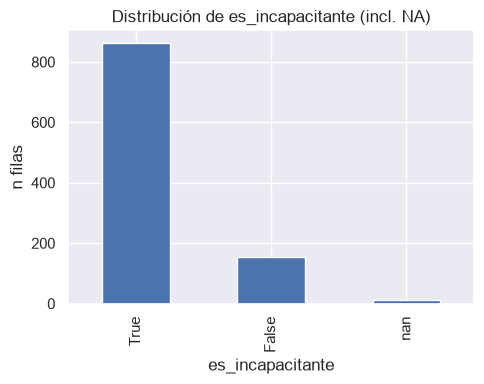

In [2]:
conteo_y = y.value_counts(dropna=False)
print(conteo_y)
print()
print((y.dropna().value_counts(normalize=True) * 100).round(2))

fig, ax = plt.subplots(figsize=(5, 4))
conteo_y.rename(index={True: "True", False: "False"}).plot(kind="bar", ax=ax)
ax.set_title("Distribución de es_incapacitante (incl. NA)")
ax.set_xlabel("es_incapacitante")
ax.set_ylabel("n filas")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "eda_dirigido_distribucion_target.png", dpi=100)

### Hallazgo

## Pregunta 2: ¿Las variables numéricas candidatas están correlacionadas entre sí?

Solo `edad_anios` y `anio` son numéricas en esta fuente (`mes` es
categórica en texto, `experiencia_puesto` quedó fuera de X — ver README
sección 5). Sirve para descartar redundancia antes de modelar, no para
medir importancia.

,edad_anios,anio
edad_anios,1.000000,0.002074
anio,0.002074,1.000000


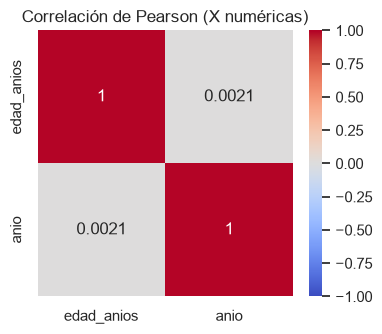

In [3]:
cols_numericas = ["edad_anios", "anio"]
corr = df[cols_numericas].corr()
display(corr)

fig, ax = plt.subplots(figsize=(4, 3.5))
sns.heatmap(corr, annot=True, vmin=-1, vmax=1, cmap="coolwarm", ax=ax)
ax.set_title("Correlación de Pearson (X numéricas)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "eda_dirigido_correlacion_numerica.png", dpi=100)

### Hallazgo

## Pregunta 3: ¿Qué tan asociadas están con `es_incapacitante` las categóricas de cardinalidad manejable?

`sexo`, `turno`, `mes`, `programa`, `area_responsabilidad`,
`actividad_realizada`. Cramér's V va de 0 (sin asociación) a 1 (asociación
perfecta) — el equivalente a una correlación para categóricas, donde
Pearson no aplica.

actividad_realizada     0.6401
programa                0.5705
area_responsabilidad    0.3440
turno                   0.2709
mes                     0.2127
sexo                    0.1589
Name: cramers_v, dtype: float64

--- sexo ---


,n,pct_incapacitante
categoria,,
M,572,81.47
F,98,65.31
-,1,0.0



--- turno ---


,n,pct_incapacitante
categoria,,
DIA,323,81.11
TARDE,220,73.64
NOCHE,136,79.41
TURNO_1,119,100.0
TURNO_2,76,100.0
TURNO_3,45,100.0


...

,n,pct_incapacitante
categoria,,
GALLETERA LIMA,115,56.52
COPSA,70,68.57
TEAL,63,98.41
SI,61,100.0
DISTRIBUCION LIMA,36,69.44
DETERGENTES,32,65.62
BOLIVIA,31,90.32
ADMINISTRACION,28,85.71
MOLINO FAUCETT,26,88.46



--- area_responsabilidad ---


,n,pct_incapacitante
categoria,,
PRODUCCION,252,93.25
DISTRIBUCION,64,100.0
ADMINISTRACION,36,80.56
GLOBAL,34,100.0
PROYECTOS,28,100.0
MANTENIMIENTO,27,96.3
VITAPRO,13,100.0
ALMACEN DE INSUMOS,13,84.62
RELACIONES LABORALES,13,100.0



--- actividad_realizada ---


,n,pct_incapacitante
categoria,,
DURANTE OPERACION PRODUCTIVA,282,87.23
DURANTE SU RUTINA DE TRABAJO,212,99.06
OTROS,75,45.33
TRASLADANDOSE A PIE,68,75.0
MANTENIMIENTO,60,98.33
CARGA/DESCARGA DE CAMION,33,100.0
TRASLADANDOSE,32,100.0
DURANTE RUTINA DE TRABAJO,32,31.25
LIMPIANDO EQUIPO,29,100.0


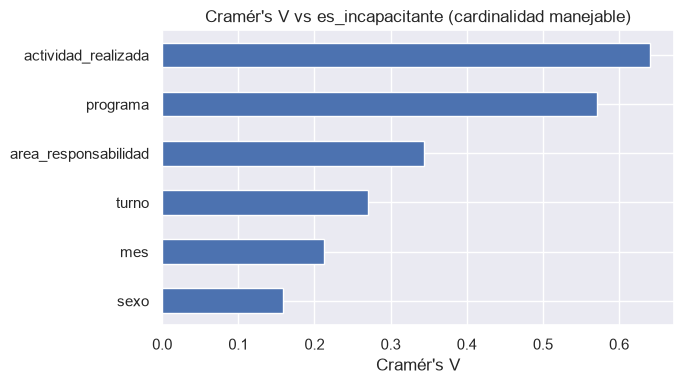

In [4]:
cols_categoricas_ok = [
    "sexo", "turno", "mes", "programa", "area_responsabilidad", "actividad_realizada"
]

v_categoricas = pd.Series(
    {col: cramers_v(df[col], y) for col in cols_categoricas_ok}, name="cramers_v"
).sort_values(ascending=False)
display(v_categoricas.round(4))

fig, ax = plt.subplots(figsize=(7, 4))
v_categoricas.plot(kind="barh", ax=ax)
ax.set_title("Cramér's V vs es_incapacitante (cardinalidad manejable)")
ax.set_xlabel("Cramér's V")
ax.invert_yaxis()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "eda_dirigido_cramers_v_manejable.png", dpi=100)

for col in cols_categoricas_ok:
    print(f"--- {col} ---")
    display(tasa_incapacitante_por_categoria(df[col], y).head(10))
    print()

### Hallazgo

## Pregunta 4: ¿Qué tan asociadas están con `es_incapacitante` las categóricas de cardinalidad muy alta?

`lugar` (371 categorías), `fuente_peligro` (359), `puesto_trabajo` (344)
sobre 1028 filas. **Cramér's V poco confiable por celdas con n<5;
interpretar solo el orden de magnitud.** Son prácticamente texto libre más
que categóricas — agruparlas requiere criterio de dominio que no tenemos
hoy (ver README, sección 9, pendiente).

--- lugar (371 categorias, top 10 por n) ---
  (poco confiable por celdas con n<5; interpretar solo el orden de magnitud)


,n,pct_incapacitante
categoria,,
COPSA,61,85.25
GALLETERA LIMA,45,95.56
DETERGENTES,42,88.1
GLOBAL,36,100.0
GALLETERA,28,28.57
NUTRICION ANIMAL TRUJILLO,27,100.0
SIDSUR,26,100.0
FIDEERIA LIMA,25,92.0
CDC,22,90.91



--- fuente_peligro (359 categorias, top 10 por n) ---
  (poco confiable por celdas con n<5; interpretar solo el orden de magnitud)


,n,pct_incapacitante
categoria,,
EQUIPO,122,100.0
PISO,55,87.27
OTROS,53,11.32
MAQUINA,38,44.74
CAMION,29,96.55
FAJA EN MOVIMIENTO,23,100.0
ESCALERA,23,91.3
PALETA,22,90.91
PUERTA,17,94.12



--- puesto_trabajo (344 categorias, top 10 por n) ---
  (poco confiable por celdas con n<5; interpretar solo el orden de magnitud)


,n,pct_incapacitante
categoria,,
PERSONAL ALICORP,100,100.0
TERCERO,88,100.0
OPERARIO DE PRODUCCION,63,90.48
AYUDANTE DE PLANTA,56,85.71
PERSONAL NO ALICORP,44,100.0
OPERARIO,31,51.61
OBRERO,30,16.67
MECANICO,18,100.0
PERSONAL TEAL,14,100.0


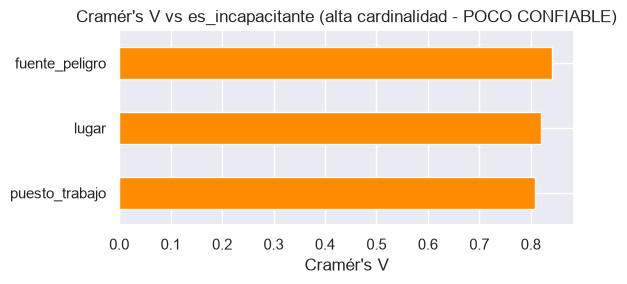

In [5]:
cols_categoricas_alta_cardinalidad = ["lugar", "fuente_peligro", "puesto_trabajo"]

v_alta_card = pd.Series(
    {col: cramers_v(df[col], y) for col in cols_categoricas_alta_cardinalidad}, name="cramers_v"
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6, 3))
v_alta_card.plot(kind="barh", ax=ax, color="darkorange")
ax.set_title("Cramér's V vs es_incapacitante (alta cardinalidad - POCO CONFIABLE)")
ax.set_xlabel("Cramér's V")
ax.invert_yaxis()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "eda_dirigido_cramers_v_alta_cardinalidad.png", dpi=100)

for col in cols_categoricas_alta_cardinalidad:
    n_cat = df[col].nunique()
    print(f"--- {col} ({n_cat} categorias, top 10 por n) ---")
    print("  (poco confiable por celdas con n<5; interpretar solo el orden de magnitud)")
    display(tasa_incapacitante_por_categoria(df[col], y).head(10))
    print()

### Hallazgo

## Pregunta 5: ¿La tasa de incapacitantes cambia a lo largo de los años (2012-2022)?

Relevante para saber si el problema es estable o está cambiando en el
tiempo — no es una X candidata nueva, `anio` ya está en la sección de
correlación numérica; aquí se mira específicamente su relación con `y`.

,n,pct_incapacitante
categoria,,
2012,51,100.0
2013,70,100.0
2014,66,100.0
2015,46,100.0
2016,74,100.0
2017,72,100.0
2018,73,100.0
2019,222,49.1
2020,111,75.68


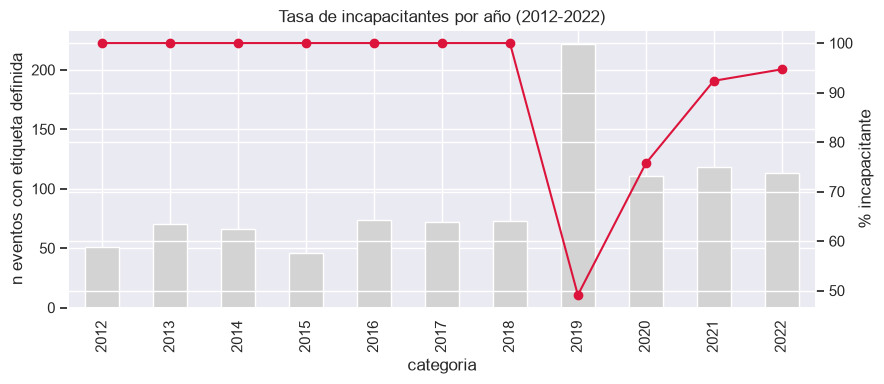

In [6]:
tasa_por_anio = tasa_incapacitante_por_categoria(df["anio"].astype("Int64").astype("category"), y)
tasa_por_anio = tasa_por_anio.sort_index()
display(tasa_por_anio)

fig, ax = plt.subplots(figsize=(9, 4))
ax2 = ax.twinx()
tasa_por_anio["n"].plot(kind="bar", ax=ax, color="lightgray", label="n")
tasa_por_anio["pct_incapacitante"].plot(kind="line", marker="o", ax=ax2, color="crimson")
ax.set_ylabel("n eventos con etiqueta definida")
ax2.set_ylabel("% incapacitante")
ax.set_title("Tasa de incapacitantes por año (2012-2022)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "eda_dirigido_tasa_incapacitante_por_anio.png", dpi=100)

### Hallazgo

## Pregunta 6: ¿La tasa de incapacitantes varía por turno/franja horaria?

Relevante directamente para la decisión de priorización (ver README,
sección 1): si un turno concentra más eventos incapacitantes, es una señal
operativa para el jefe de SST, no solo un dato descriptivo.

,n,pct_incapacitante
categoria,,
TURNO_1,119,100.0
TURNO_2,76,100.0
TURNO_3,45,100.0
DIA,323,81.11
NOCHE,136,79.41
TARDE,220,73.64


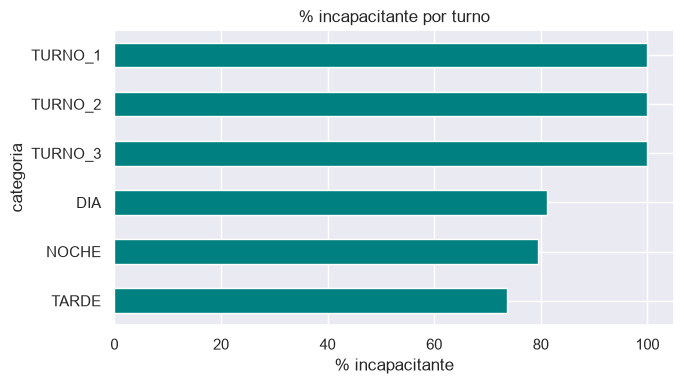

In [7]:
tasa_por_turno = tasa_incapacitante_por_categoria(df["turno"], y).sort_values(
    "pct_incapacitante", ascending=False
)
display(tasa_por_turno)

fig, ax = plt.subplots(figsize=(7, 4))
tasa_por_turno["pct_incapacitante"].plot(kind="barh", ax=ax, color="teal")
ax.set_title("% incapacitante por turno")
ax.set_xlabel("% incapacitante")
ax.invert_yaxis()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "eda_dirigido_tasa_incapacitante_por_turno.png", dpi=100)

### Hallazgo

## Pendiente

- [ ] Completar las 6 celdas `### Hallazgo` de arriba con la lectura del
      equipo — este notebook solo calcula, no interpreta (ver CLAUDE.md).
- [ ] `lugar`, `fuente_peligro`, `puesto_trabajo` necesitan una regla de
      agrupación por criterio de dominio antes de usarse con confianza en un
      modelo — no se decidió en esta pasada.
- [ ] `experiencia_puesto` sigue fuera de X (texto libre, unidades
      mezcladas) — normalizarla es una fase futura.
- [ ] Decidir el caso a caso de las 2 filas de `gravedad` pendientes
      ("ACCIDENTE FUERA DEL TRABAJO", "DAÑO A LA SALUD") — hoy quedan como
      `es_incapacitante = NA`, excluidas de este análisis.